# FScanpy：完整序列 PRF 预测结果解读

本教程使用新版 **PyTorch 短模型 HistGradientBoosting 与长模型 BiLSTM-CNN**，参考原始样本的完整结果选择案例：参考区域相对突出、峰高相近但局部支持不同，以及多个强信号区域仍存在歧义。

主体含四个来自重建 test 窗口划分的案例，另有一个明确标注为 train 的低背景教学补充。每个案例均扫描**完整 CDS**。先查看全序列曲线，再检查局部区域。

可同时参考[旧版模型已执行结果](predict_sample_legacy_zh.ipynb)和[历史保存结果归档](predict_sample_legacy_saved_zh.ipynb)。归档保留全部六张原图；其中代码与输出来自不同历史执行状态，因此只作为保存快照阅读。

[English](predict_sample.ipynb) | **中文**

## 1. 加载模型和示例序列

使用已安装 FScanpy、pandas 和 matplotlib 的 Python 内核，将随附的 `data` 文件夹与 notebook 一起保留。下面的模型检查可避免把旧版双树模型的输出误当成新版 PyTorch 结果。

中文版与英文版使用相同计算和绘图布局。图内保留通用英文标签，正文解释它们的含义，便于逐图对照。

In [1]:
import inspect
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from FScanpy import PRFPredictor

torch.set_num_threads(1)
# 官方发布版自动使用 PyTorch；双后端开发版本需要显式选择。
# 这样可避免使用双后端实现默认的 TensorFlow 模型。
if "backend" in inspect.signature(PRFPredictor).parameters:
    predictor = PRFPredictor(backend="pytorch")
else:
    predictor = PRFPredictor()
assert isinstance(predictor.long_model, torch.nn.Module), "本教程需要新版 PyTorch 长模型。"

data_folder = Path("data")
if not data_folder.is_dir():
    data_folder = Path("tutorial") / "data"
examples = pd.read_csv(data_folder / "predict_sample_examples.csv")
records = examples.set_index("prf_id")
display(examples.drop(columns="Full_Sequence"))

,prf_id,DNA_seqid,source,split,Genome,Product,length,reference_codon_start_0based
0,PRF_0817,JN698994.1,SEAPHAGES,test,Mycobacterium phage DS6A,tail assembly chaperone,780,297.0
1,PRF_1075,MN234184.1,SEAPHAGES,test,Mycobacterium phage IdentityCrisis,tail assembly chaperone,705,309.0
2,PRF_0837,Efeko,SEAPHAGES,test,Microbacterium phage Efeko,tail assembly chaperone,423,249.0
3,PRF_1047,Hiyaa,SEAPHAGES,test,Streptomyces phage Hiyaa,tail assembly chaperone,759,543.0
4,PRF_0072,NC_003919.1,FSDB,train,Xanthomonas citri pv. citri str. 306,IS3 family transposase,1089,252.0


test 身份来自训练 notebook 的分层窗口划分重建，并通过精确序列匹配连接到完整 CDS。这四个 test 案例已排除发现的训练窗口、中心 33 bp、同一 CDS 以及 validation CDS 的精确重叠。尚未进行同源独立性验证，模型文件也未保存训练成员清单。这些精选阳性案例用于教学，不用于估计测试准确率。

搜索检查了 168 条排重后的 test CDS 和另外 217 条 train CDS。在该范围内，没有找到与旧版最干净案例严格对应的“单峰、无歧义”结果。后文 train 案例仅作教学补充，不能作为 test 性能证据。

## 2. 阅读与原版一致的图形

全序列图保留原版结构：**上方两个粗红色热图，下方黑色柱状图**。局部比较也采用相同结构。

- **FS site (predicted candidates)**：标记通过显示过滤且集成分数至少为 0.8 的预测候选。它来自模型输出，并非实验验证的真实注释。原绘图方法会扩大标记宽度以便观察。
- **Prediction**：以红色热图显示过滤后的集成分数，其标记同样具有显示宽度。
- **柱状图**：显示每个扫描位置经同一显示过滤后的分数。绿色虚线单独标记参考密码子的起点，不由热图推断真实位置。

每 3 nt 扫描一次，短模型内部门控为 0.1，两个模型的显示阈值均为 0.2。主体固定 `ensemble_weight=0.6`，与旧教程多数示例相同：`ensemble = 0.6 × short + 0.4 × long`。API 默认权重为 0.4，后文另做对照。

坐标为从 0 开始的密码子起点。参考起点 `p` 对应密码子 `p,p+1,p+2`，在从 1 开始的写法中为 `p+1` 到 `p+3`。参考附近出现高峰，不等于精确定位成功。

In [2]:
PARAMS = dict(window_size=3, short_threshold=0.2, long_threshold=0.2, ensemble_weight=0.6)
results_by_id = {}
figures_by_id = {}

def plot_example(prf_id):
    row = records.loc[prf_id]
    result, figure = predictor.plot_sequence_prediction(
        str(row.Full_Sequence), **PARAMS,
        title=f"{prf_id} | {row.source} | {row['split']} | complete CDS",
        figsize=(14, 8), dpi=120,
    )
    # 保留原版热图及柱状图，并加粗热图面板。
    grid = figure.axes[0].get_subplotspec().get_gridspec()
    grid.set_height_ratios([0.35, 0.35, 2.8])
    figure.axes[0].set_title("FS site (predicted candidates)", fontsize=10)
    figure.axes[1].set_title("Prediction", fontsize=10)
    reference = int(row.reference_codon_start_0based)
    for axis in figure.axes:
        axis.axvline(reference, color="#009E73", linestyle="--", linewidth=1.2)
    figure.axes[2].set_xlabel("Codon start (0-based nt)")
    figure.axes[2].set_ylabel("Filtered ensemble score")
    figure.axes[2].plot([], [], color="#009E73", linestyle="--", label=f"Reference {reference}")
    figure.axes[2].legend(loc="upper right", fontsize=9)
    figure.tight_layout(rect=(0, 0, 1, 0.94))
    results_by_id[prf_id] = result
    figures_by_id[prf_id] = figure
    return result, figure

def visible_scores(result):
    mask = (result.Short_Probability >= 0.2) & (result.Long_Probability >= 0.2)
    return result.Ensemble_Probability.where(mask, 0)

def compare_regions(result, centers):
    """在等宽局部窗口中比较已有密码子预测。"""
    scores = visible_scores(result)
    figure = plt.figure(figsize=(14, 5.3))
    grid = figure.add_gridspec(3, len(centers), height_ratios=[0.35,0.35,2.8], hspace=0.5)
    summary = []
    for column, (label, center) in enumerate(centers):
        local = (result.Position-center).abs() <= 15
        count = int((scores[local] >= 0.7).sum())
        summary.append(dict(region=label, center=center, high_score_codons=count,
                            scanned_codons=int(local.sum()), local_max=float(scores[local].max())))
        # 局部图同样保留候选条带热图和分数热图。
        candidate_strip = np.zeros((1,33))
        score_strip = np.zeros((1,33))
        for position, score in zip(result.loc[local,"Position"], scores[local]):
            index = int(position-center)+16
            score_strip[0,index] = score
            if score >= 0.8:
                candidate_strip[0,max(0,index-1):min(33,index+2)] = 1
        top = figure.add_subplot(grid[0,column])
        middle = figure.add_subplot(grid[1,column])
        for heatmap, strip in [(top,candidate_strip),(middle,score_strip)]:
            heatmap.imshow(strip,cmap="Reds",aspect="auto",vmin=0,vmax=1,
                           interpolation="nearest",extent=(-16.5,16.5,0,1))
            heatmap.set_xticks([]); heatmap.set_yticks([])
        top.set_title(f"{label}: {center}\nFS site (predicted candidates)",fontsize=9)
        middle.set_title("Prediction",fontsize=9)
        axis = figure.add_subplot(grid[2,column])
        axis.bar(result.loc[local, "Position"]-center, scores[local], color="black", alpha=0.6, width=1)
        axis.axhline(0.7, color="gray", linestyle=":", linewidth=1)
        axis.set(xlim=(-16.5,16.5), ylim=(0,1.03), xlabel="Offset from center (nt)",
                 title=f"Score >= 0.7: {count} codons")
        axis.set_xticks([-15,0,15]); axis.grid(axis="y", alpha=0.2)
        if column==0:axis.set_ylabel("Filtered ensemble score")
    figure.tight_layout()
    return pd.DataFrame(summary), figure

## 3. 参考区域相对突出：PRF_0817（test）

这条 SEAPHAGES CDS 长 780 nt，参考起点为 **297**。**300** 附近的峰约为 **0.963**，远处最强峰在 **9** 附近，约为 **0.891**。参考位置 ±15 nt 内有 5 个密码子的显示分数至少为 0.7。

参考区域值得优先考虑，但全序列仍有其他高峰，因此不能描述为完全无歧义。对旧版 Sequence 0 也应作同样谨慎的解读：其参考峰之外还有较强次峰。

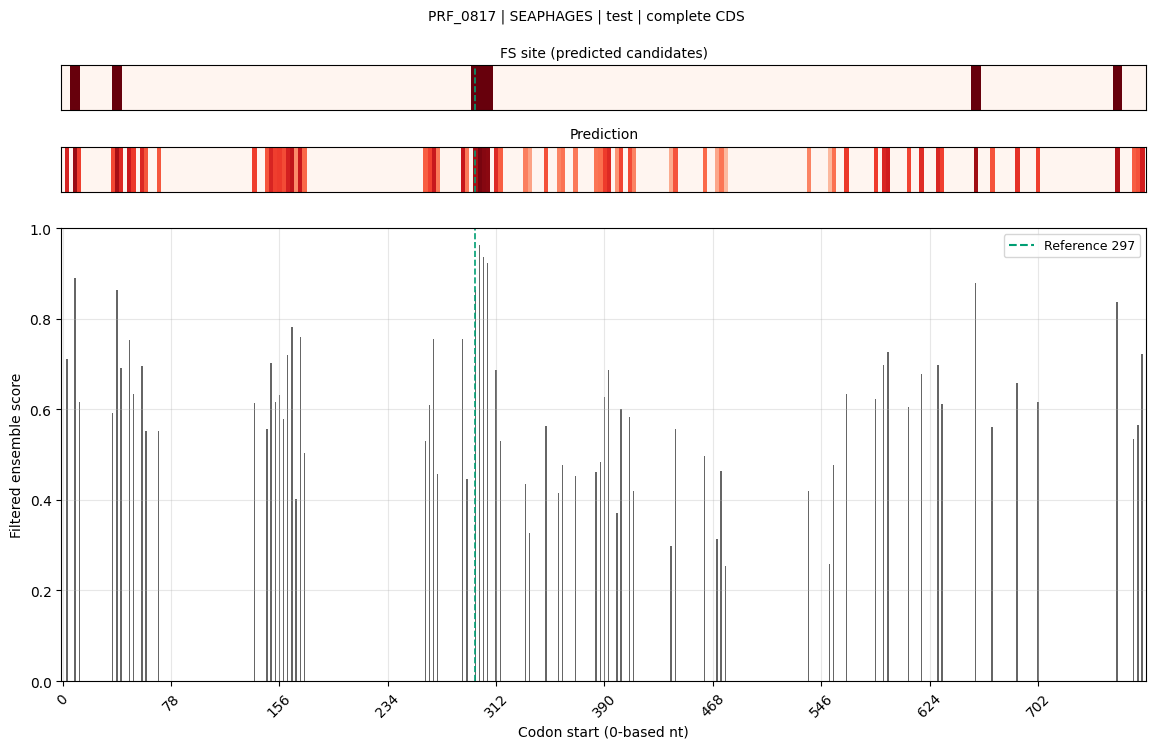

,region,center,high_score_codons,scanned_codons,local_max
0,Reference,297,5,11,0.963053
1,Competitor,9,2,9,0.890966
2,Competitor,657,1,11,0.878959
3,Competitor,759,1,11,0.836836


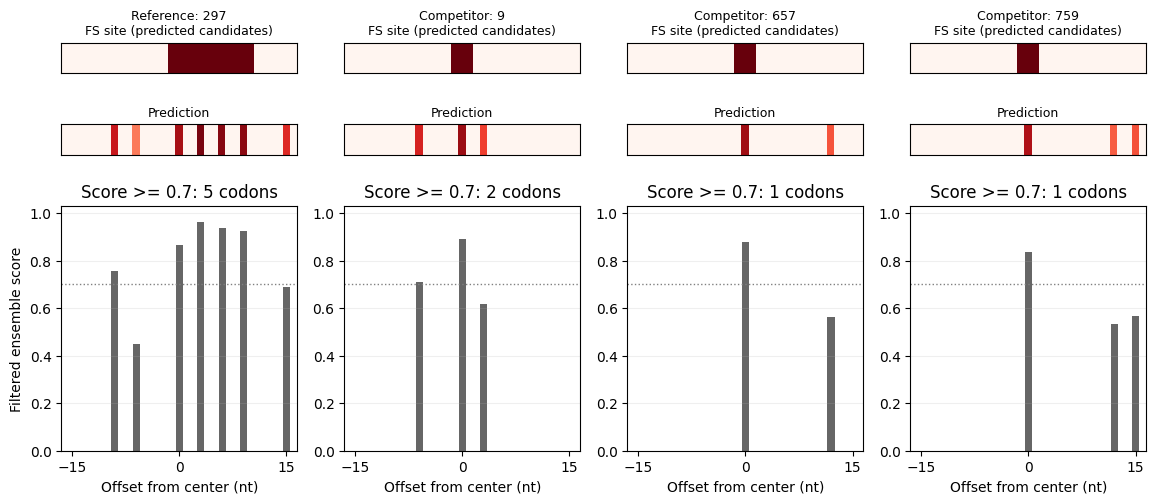

In [3]:
result, figure = plot_example("PRF_0817")
plt.show()
local_summary, figure = compare_regions(result, [("Reference",297), ("Competitor",9), ("Competitor",657), ("Competitor",759)])
display(local_summary)
plt.show()

## 4. 峰高相近，但局部支持不同：PRF_1075（test）

这条 SEAPHAGES CDS 长 705 nt，参考起点为 **309**。附近 **312** 的峰约为 **0.9755**，远处 **645** 的峰约为 **0.9761**。仅按峰高会优先选择远处候选。

在等宽的 ±15 nt 窗口中，参考区域有 **6** 个显示分数至少为 0.7 的密码子，645 区域只有 **1** 个，252 区域有 **2** 个；48 附近另有 **5** 个。参考区域的集中信号可提供支持，但不能确认 PRF 事件，也不能排除其他区域。这比仅挑选参考峰排名靠前的样本，更符合旧版 Sequence 1 展示的情形。

相邻窗口高度重叠，分数具有相关性；密集峰群不代表多次独立验证。645 的 399 bp 窗口还需要右端补 N，而参考 309 和竞争区域 252 具有完整上下文。

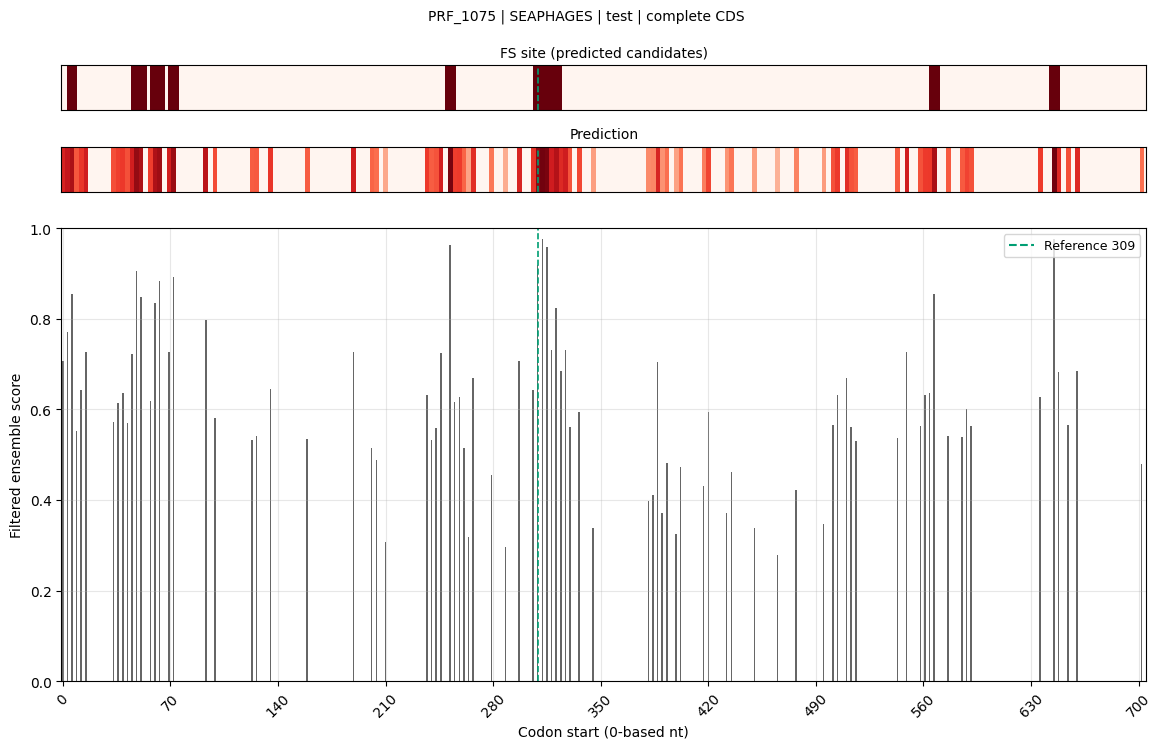

,region,center,high_score_codons,scanned_codons,local_max
0,Reference,309,6,11,0.975485
1,Competitor,645,1,11,0.976088
2,Competitor,252,2,11,0.962624
3,Competitor,48,5,11,0.905637


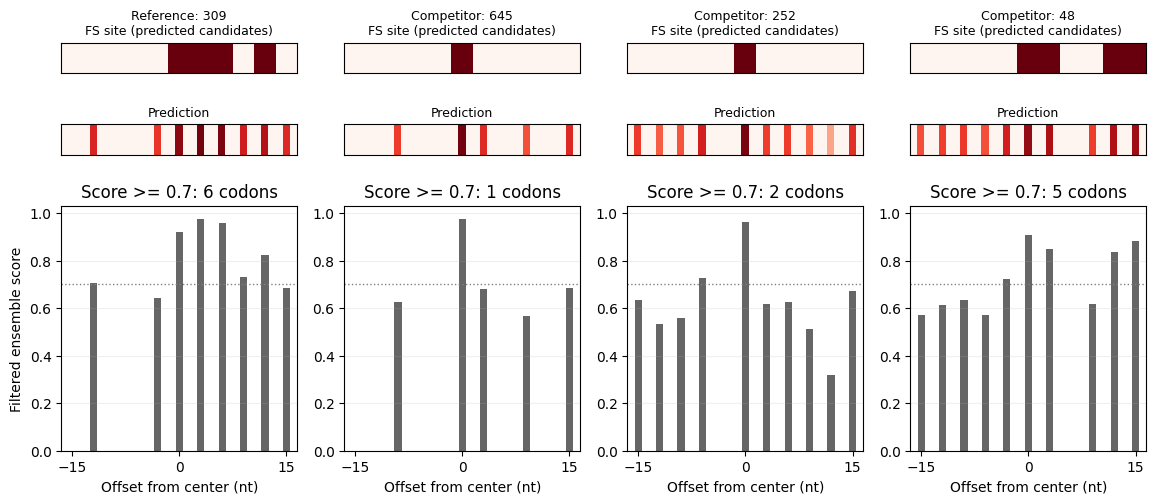

In [4]:
result, figure = plot_example("PRF_1075")
plt.show()
local_summary, figure = compare_regions(result, [("Reference",309), ("Competitor",645), ("Competitor",252), ("Competitor",48)])
display(local_summary)
plt.show()

## 5. 短 CDS 的峰群密度比较：PRF_0837（test）

这条 SEAPHAGES CDS 长 423 nt，与旧版 429 nt 样本长度相近。参考起点为 **249**，其峰约为 **0.9995**；远处 **330** 的峰也达到约 **0.9949**。

参考位置 ±15 nt 内有 **10** 个显示分数至少为 0.7 的密码子，330 附近只有 **1** 个，6 附近有 **2** 个。即使完整曲线存在很强的背景峰，局部对比仍能提供信息。但此例展示的是短序列中的密集区域，并非旧版“几乎只有一个明显峰”的复现。参考位置的 399 bp 窗口需要右端补 N。

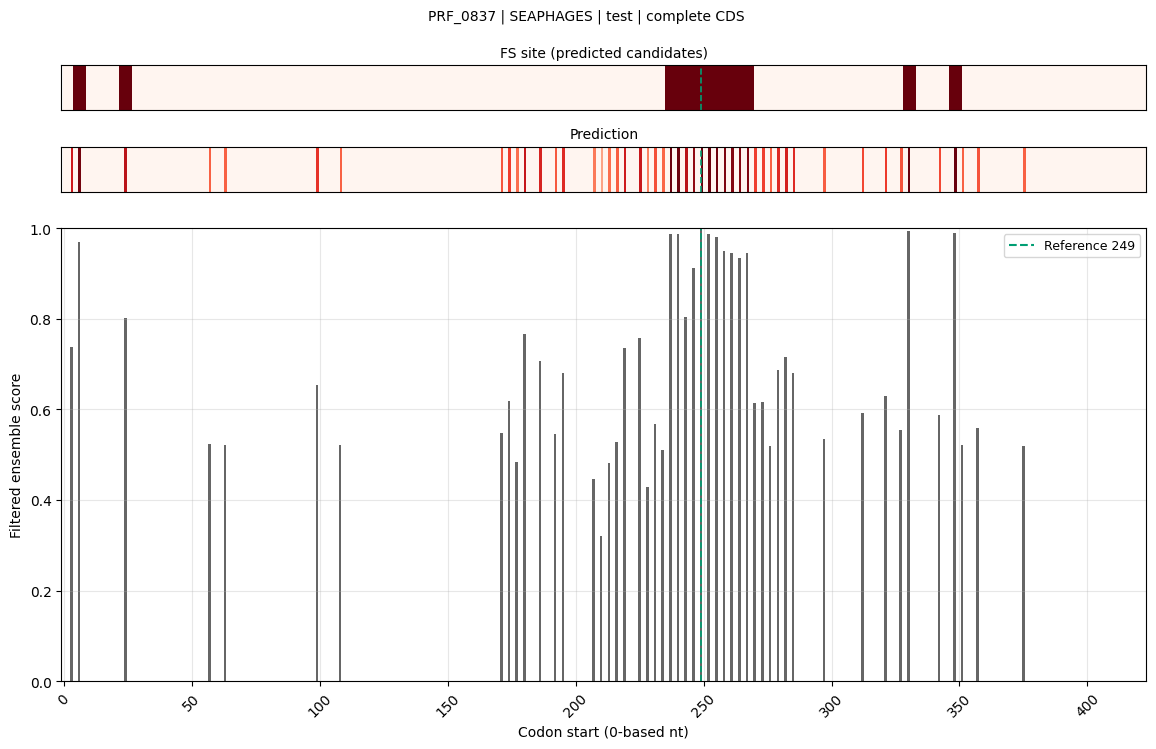

,region,center,high_score_codons,scanned_codons,local_max
0,Reference,249,10,11,0.999480
1,Competitor,330,1,11,0.994856
2,Competitor,6,2,8,0.969400
3,Competitor,180,2,11,0.765846


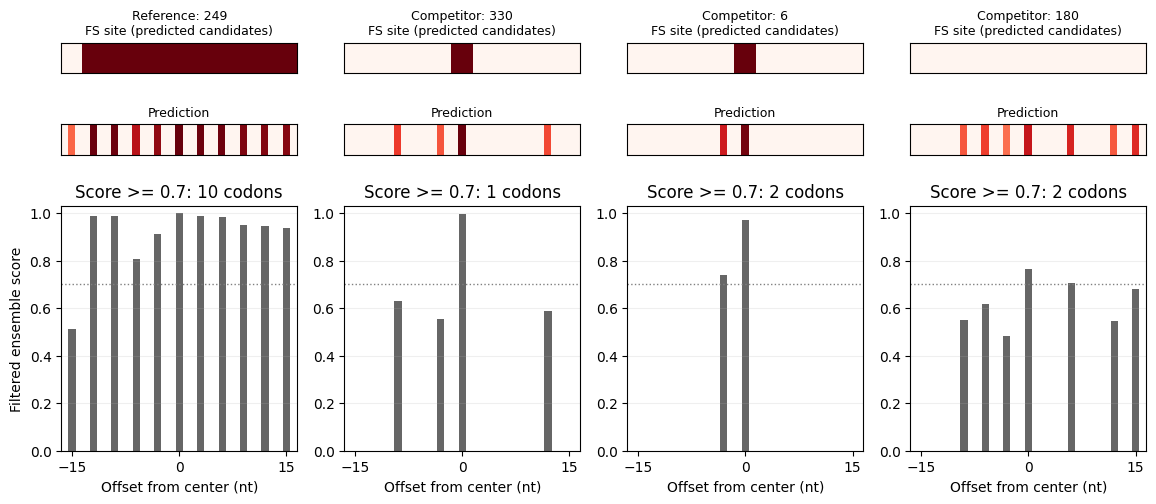

In [5]:
result, figure = plot_example("PRF_0837")
plt.show()
local_summary, figure = compare_regions(result, [("Reference",249), ("Competitor",330), ("Competitor",6), ("Competitor",180)])
display(local_summary)
plt.show()

## 6. 多个强信号区域仍有歧义：PRF_1047（test）

这条 SEAPHAGES CDS 长 759 nt，参考起点为 **543**，其分数约为 **0.978**；**24、672、72** 附近的竞争峰分别约为 **0.998、0.997、0.996**。

参考位置 ±15 nt 内有 **5** 个显示分数至少为 0.7 的密码子，三个竞争区域分别有 **3、4、7** 个。峰高和局部密度均不能给出唯一答案。这对应旧版 Sequence 14 的情形，需要结合其他生物学证据或实验验证。

最强的三个竞争区域在构建 399 bp 窗口时都需要端部补 N，而参考 543 具有完整上下文。这个差异值得考虑，但不能自动把边界峰判为假阳性。

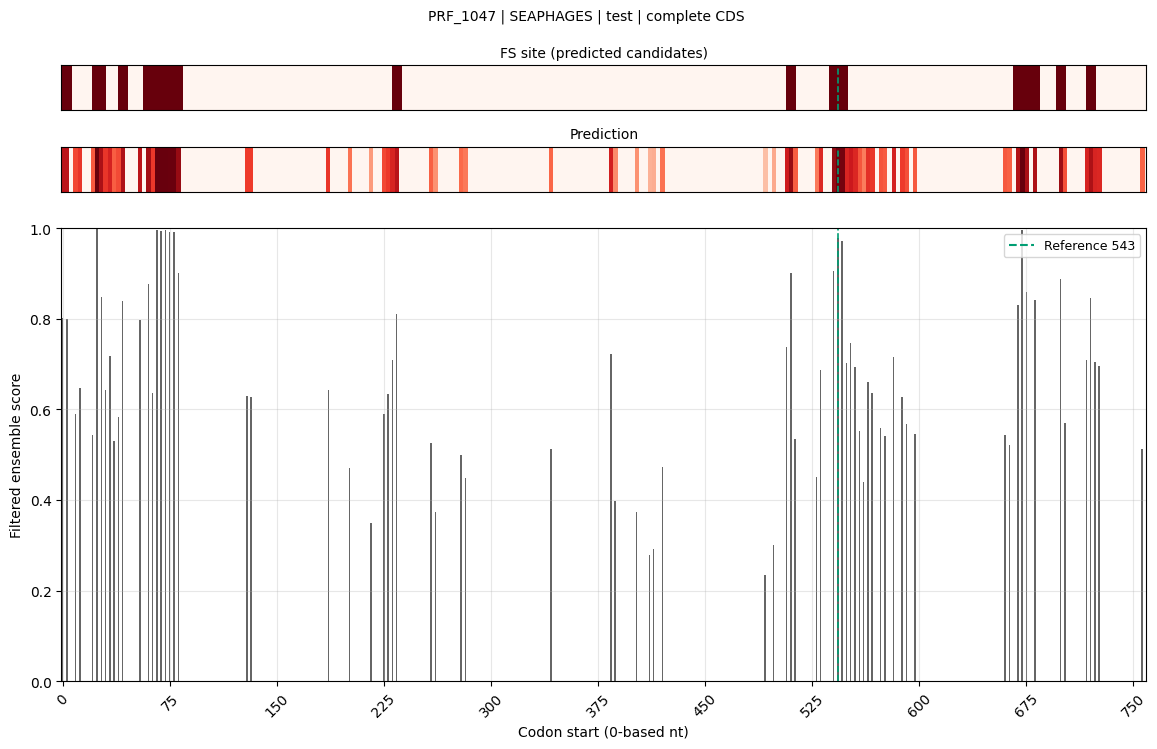

,region,center,high_score_codons,scanned_codons,local_max
0,Reference,543,5,11,0.978280
1,Competitor,24,3,11,0.997771
2,Competitor,672,4,11,0.997125
3,Competitor,72,7,11,0.995848


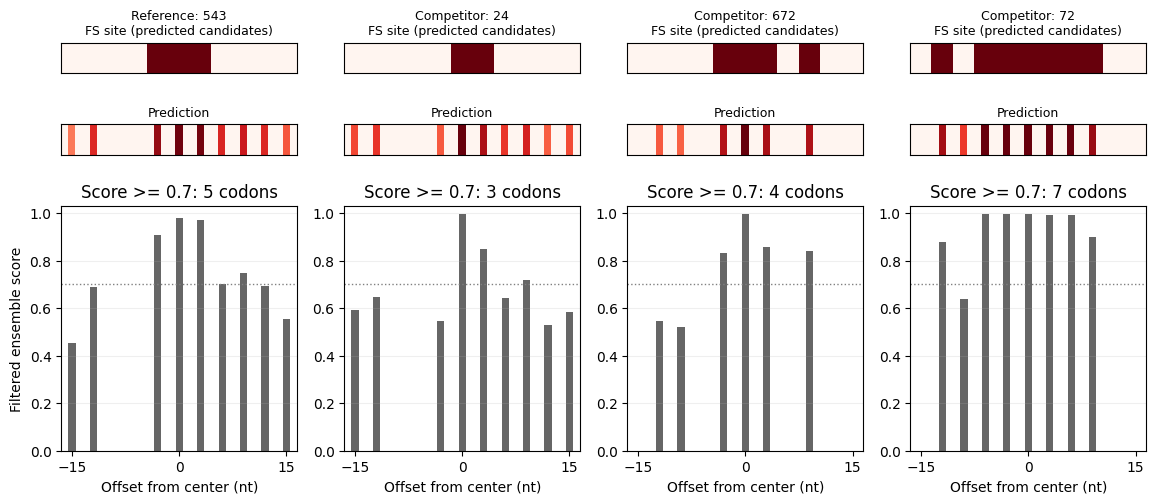

In [6]:
result, figure = plot_example("PRF_1047")
plt.show()
local_summary, figure = compare_regions(result, [("Reference",543), ("Competitor",24), ("Competitor",672), ("Competitor",72)])
display(local_summary)
plt.show()

## 7. 可选的低背景教学补充：PRF_0072（train）

这条 FSDB CDS 长 1089 nt，属于 **train**，其结果不能计为 test 性能。在当前权重下，约 14% 的扫描位置通过显示过滤，约 2.2% 的位置得分至少为 0.7，可补充旧样本中较稀疏背景的教学情形。

参考起点为 **252**，附近最高峰在 **258**，约为 **0.970**，有 6 nt 偏差。远处 **912** 仍有约 **0.909** 的峰，711 和 819 附近也有候选。即使背景较低，本例仍不是严格单峰，也未精确定位。

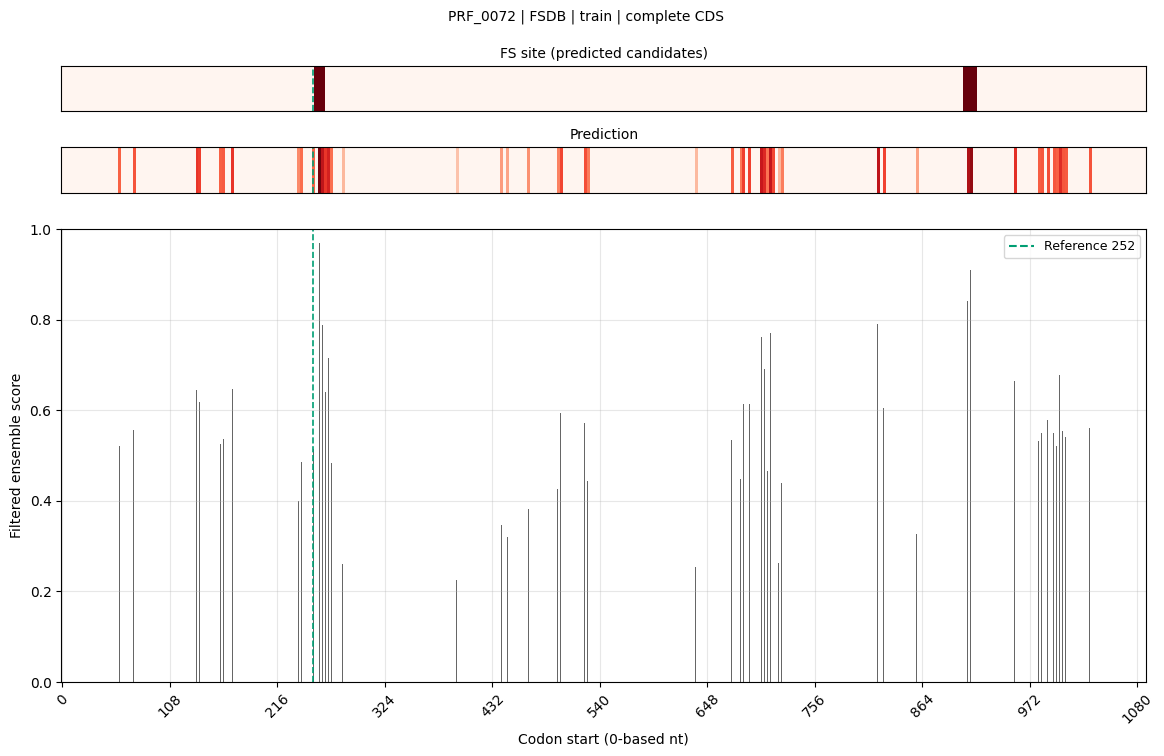

,region,center,high_score_codons,scanned_codons,local_max
0,Reference,252,3,11,0.969608
1,Competitor,912,2,11,0.909088
2,Competitor,819,1,11,0.789247
3,Competitor,711,2,11,0.770667


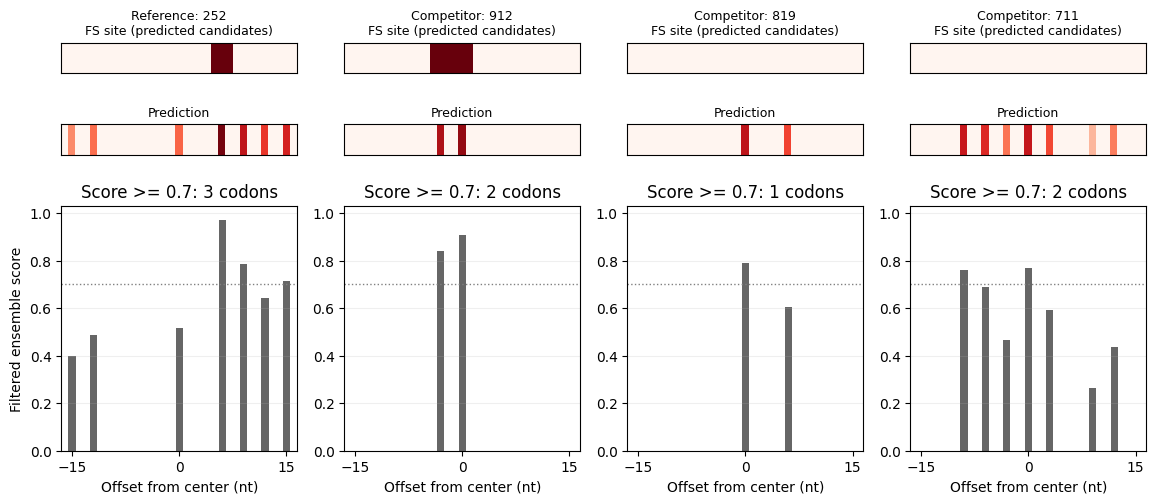

In [7]:
result, figure = plot_example("PRF_0072")
plt.show()
local_summary, figure = compare_regions(result, [("Reference",252), ("Competitor",912), ("Competitor",819), ("Competitor",711)])
display(local_summary)
plt.show()

## 8. 改变扫描步长实际增加了什么

当前 API 提取窗口时，会把请求位置向下归到密码子起点。因此 `p、p+1、p+2` 使用同一组输入窗口。**把 `window_size` 从 3 改为 1，增加的是重复输出行，而不是独立的单核苷酸预测。**

应通过原始密码子预测的局部视图检查峰群。重复输出让柱状图看起来更密集，并不构成对参考位置的额外确认。这修正了旧教程中不适用于当前实现的“高分辨率确认”解释。

In [8]:
coarse = results_by_id["PRF_1075"]
fine = predictor.predict_sequence(str(records.loc["PRF_1075", "Full_Sequence"]),
                                  window_size=1, short_threshold=0.1, ensemble_weight=0.6)
probability_columns = ["Short_Probability", "Long_Probability", "Ensemble_Probability"]
snapped = (fine.Position//3*3).to_numpy()
expected = coarse.set_index("Position").loc[snapped, probability_columns].to_numpy()
np.testing.assert_allclose(fine[probability_columns].to_numpy(), expected, atol=5e-4, rtol=0)
display(fine.loc[fine.Position.between(309,314), ["Position"]+probability_columns])

,Position,Short_Probability,Long_Probability,Ensemble_Probability
309,309,0.986363,0.818697,0.919297
310,310,0.986363,0.818697,0.919297
311,311,0.986363,0.818697,0.919297
312,312,0.986529,0.958919,0.975485
313,313,0.986529,0.958919,0.975485
314,314,0.986529,0.958919,0.975485


## 9. 集成权重的敏感性

旧版多数示例使用短模型权重 0.6，但 API 默认值及旧版 Sequence 14 歧义例使用 0.4。两种设置不能视为可以直接互换。

下面把同一组 short/long 输出按两种权重重新组合。权重为 0.4 时，PRF_1075 的 645 区域有 5 个密码子得分至少为 0.7，48 区域则有 10 个。因此，权重 0.6 下观察到的密度优势依赖于具体配置。解读候选时应同时考虑这两组结果。

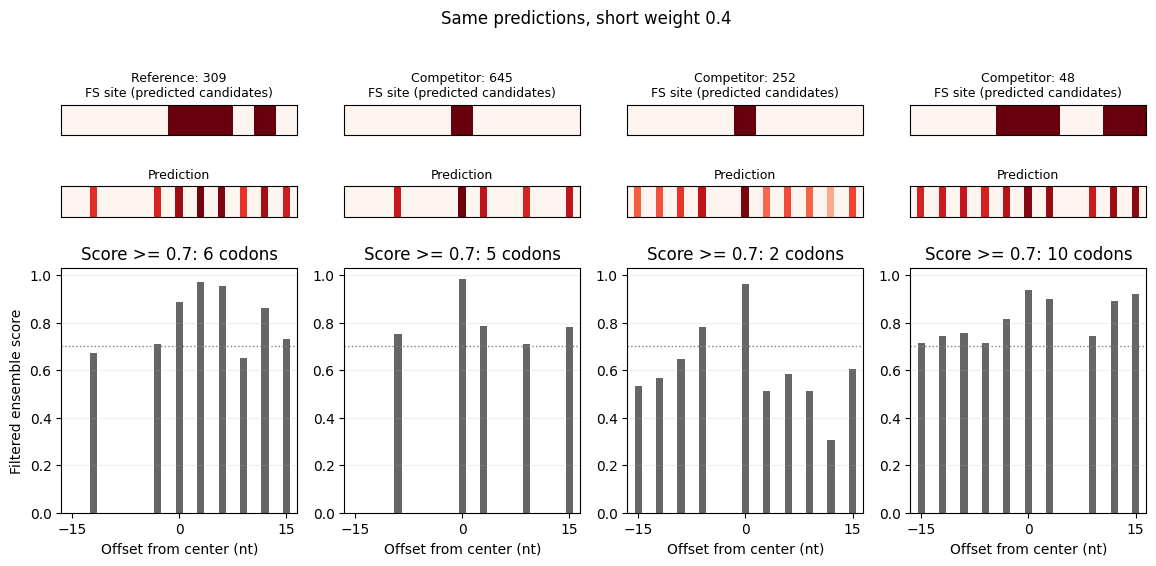

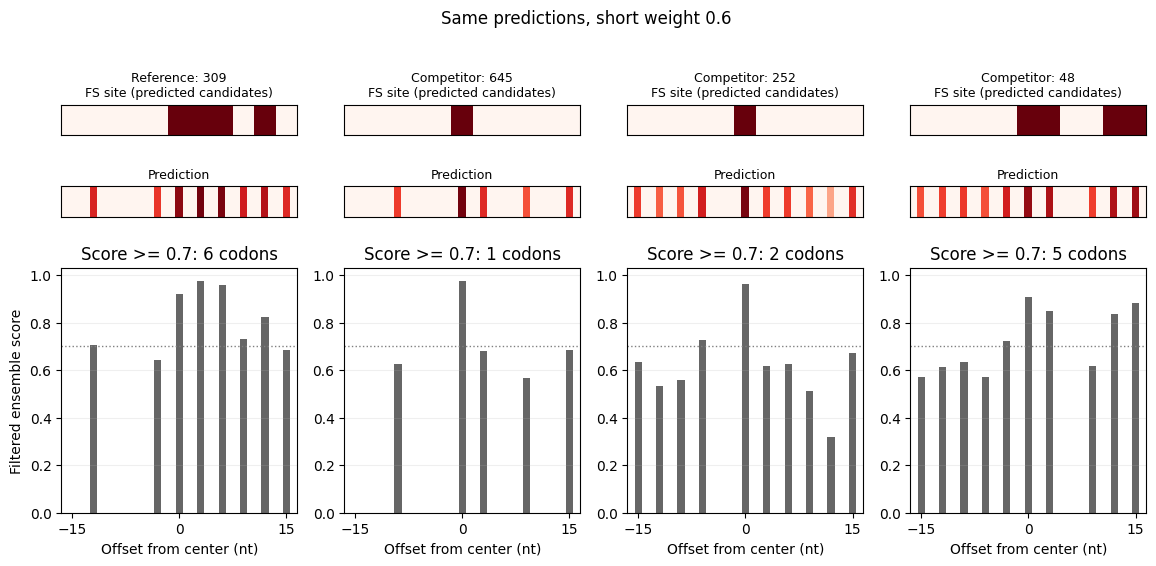

,short_weight,region,center,high_score_codons,scanned_codons,local_max
0,0.4,Reference,309,6,11,0.969963
1,0.4,Competitor,645,5,11,0.983889
2,0.4,Competitor,252,2,11,0.962881
3,0.4,Competitor,48,10,11,0.935613
4,0.6,Reference,309,6,11,0.975485
5,0.6,Competitor,645,1,11,0.976088
6,0.6,Competitor,252,2,11,0.962624
7,0.6,Competitor,48,5,11,0.905637


In [9]:
weight_comparison = []
for weight in [0.4,0.6]:
    adjusted = results_by_id["PRF_1075"].copy()
    adjusted.Ensemble_Probability = np.where(adjusted.Short_Probability >= 0.1,
        weight*adjusted.Short_Probability+(1-weight)*adjusted.Long_Probability, 0)
    table, figure = compare_regions(adjusted, [("Reference",309), ("Competitor",645), ("Competitor",252), ("Competitor",48)])
    table.insert(0,"short_weight",weight); weight_comparison.append(table)
    figure.suptitle(f"Same predictions, short weight {weight}", y=1.06)
    plt.show()
display(pd.concat(weight_comparison,ignore_index=True))

## 10. 后端及参考窗口的差异

本教程使用官方 **PyTorch 33 / 399 bp** 模型。另一套双后端开发实现提供 TensorFlow 30 / 300 bp 模型，使用不同的特征流程和 Voting 分类器。其分数不能直接与 PyTorch 比较，`ensemble_weight` 也不像 PyTorch 那样控制 Voting 输出。该实现还存在由 set 导致的特征列顺序复现问题；在把结果用于可复现教程前，应先确认训练时的特征顺序。官方 PyTorch 发布版不提供这一后端选择接口。

复现上面的图时，应保留原生扫描窗口约定。重建训练元数据中的窗口以密码子中间核苷酸为中心，而原生扫描以第一个核苷酸为中心。相差 1 nt 就可能改变结果；这种变化必须单独标为诊断对照，不能悄悄混入原生预测。

处理自己的序列时，应输入编码方向一致的完整 DNA CDS，并核对阅读框。保留完整预测表，比较竞争区域，再用独立证据支持功能结论。开头链接的旧版 notebook 保留旧模型结果和历史原图，方便对照。